# Employee Attrition Prediction & Analysis
### Portfolio Project: Machine Learning & HR Analytics

In this notebook, we build, evaluate, and compare two different machine learning models (**Logistic Regression** and **Random Forest Classifier**) to predict employee turnover. Our goal is to identify the primary drivers of attrition and evaluate whether linear models or non-linear ensemble methods handle human resources data more effectively.

In [1]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# Set styling preferences for visualizations
sns.set_theme(style="whitegrid")

## Aggregated Data Review
Before looking at individual employee records, we load and analyze aggregated organizational data (`df_agg`). This allows us to examine macro-level metrics, such as baseline attrition rates and distributions across departments and management groups.

In [3]:
# Load aggregate data from SQL export
df_agg = pd.read_csv('../csv/attrition_aggregate.csv', sep='\t')

# View basic structure
print("--- Aggregate Dataset Info ---")
print(df_agg.info())

print("\n--- First 5 Rows ---")
display(df_agg.head())

--- Aggregate Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   department_name         85 non-null     str    
 1   management_tier         85 non-null     str    
 2   total_headcount         85 non-null     int64  
 3   total_attrition_count   85 non-null     int64  
 4   attrition_rate_pct      85 non-null     float64
 5   avg_base_salary         85 non-null     float64
 6   avg_tenure_years        85 non-null     float64
 7   avg_performance_rating  85 non-null     float64
dtypes: float64(4), int64(2), str(2)
memory usage: 5.4 KB
None

--- First 5 Rows ---


,department_name,management_tier,total_headcount,total_attrition_count,attrition_rate_pct,avg_base_salary,avg_tenure_years,avg_performance_rating
0,Customer Success,Manager,6,2,33.33,91504.92,2.96,3.17
1,Supply Chain,Domain Director,3,1,33.33,143455.77,2.00,2.67
2,Data Science,Assistant Manager,10,3,30.00,82607.91,2.13,3.70
3,Finance,Assistant Manager,7,2,28.57,77821.89,2.67,2.43
4,Supply Chain,Assistant Manager,7,2,28.57,88442.30,2.79,3.00


### Departmental Attrition Analysis
We visualize the trailing attrition rate across different organizational departments to spot high-level macro trends before modeling individual risk factors.

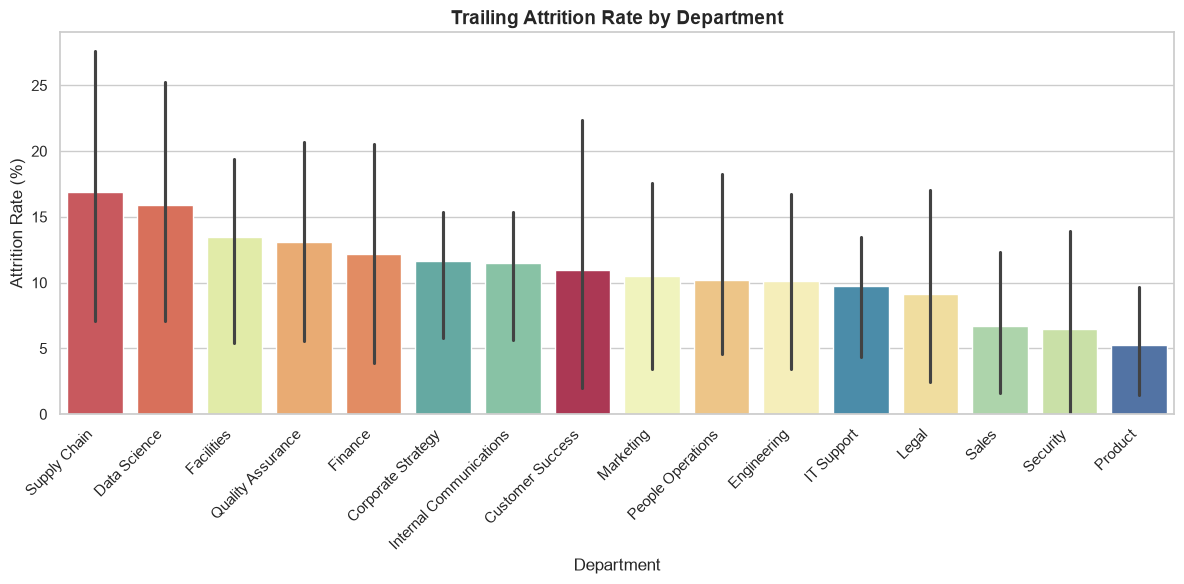

In [4]:
# Sort and Graph the dataframe by attrition rate from highest to lowest
dept_order = (
    df_agg.groupby('department_name')['attrition_rate_pct']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_agg,
    x='department_name',
    y='attrition_rate_pct',
    palette='Spectral',
    hue='department_name',
    legend=False,
    order=dept_order
)

plt.xticks(rotation=45, ha='right')
plt.title('Trailing Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

### Management Group Attrition Breakdown
Next, we examine how turnover rates cluster across different management and leadership groups to see if leadership structures impact retention.

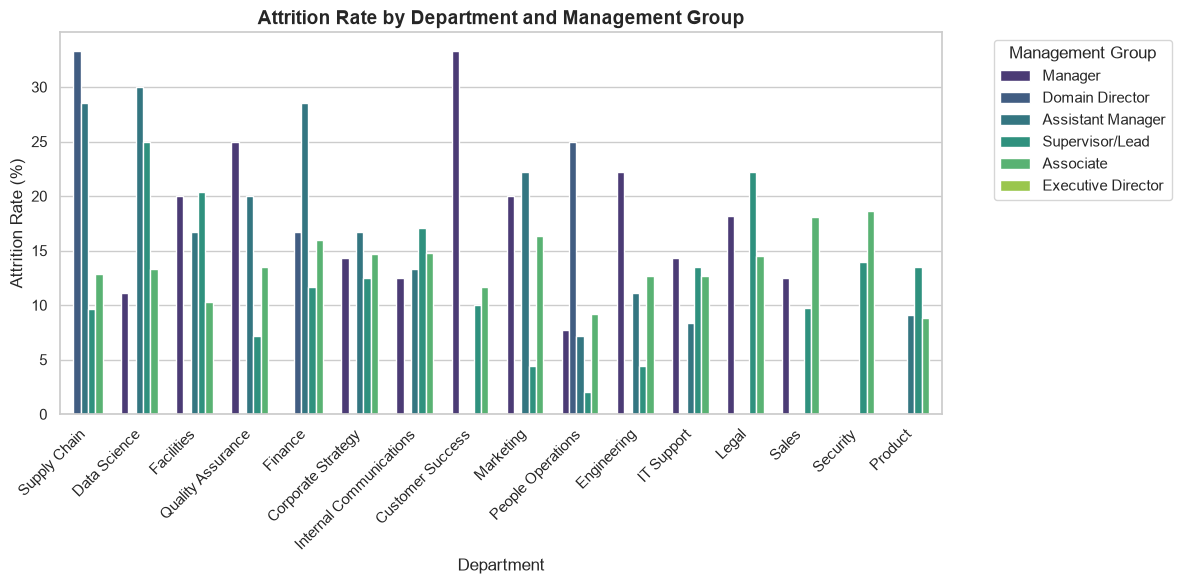

In [5]:
# Aggregated attrition per management group among department
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_agg,
    x='department_name',
    y='attrition_rate_pct',
    hue='management_tier',
    palette='viridis',
    order=dept_order
)

plt.xticks(rotation=45, ha='right')
plt.title('Attrition Rate by Department and Management Group', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.legend(title='Management Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Employee Level Attrition Prediction
### 1. Data Loading and Initial Audit
We begin by loading our employee dataset and inspecting its structural integrity, missing values, and data types.

In [6]:
# Load employee level dataframe
df_ee = pd.read_csv('../csv/attrition_employees.csv', sep='\t')

# Display the first 5 rows
display(df_ee.head())

# Check shape, data types, and missing values
print("\n--- Dataset Info ---")
display(df_ee.info())

print("\n--- Missing Value Counts ---")
print(df_ee.isnull().sum())

,base_salary,performance_rating,tenure_years,age,engagement_score,manager_satisfaction,work_life_balance_score,is_attrition
0,49029.13,5,4.9370,35,9.99,5.00,8.0,0
1,95178.25,4,3.2877,47,9.00,NaN,9.0,0
2,51981.85,3,4.6384,35,8.00,9.99,9.0,0
3,64834.07,3,4.6712,41,5.00,3.00,1.0,0
4,60349.33,3,1.3507,38,5.00,6.00,1.0,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4228 entries, 0 to 4227
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   base_salary              4228 non-null   float64
 1   performance_rating       4228 non-null   int64  
 2   tenure_years             4088 non-null   float64
 3   age                      4228 non-null   int64  
 4   engagement_score         3868 non-null   float64
 5   manager_satisfaction     3769 non-null   float64
 6   work_life_balance_score  3762 non-null   float64
 7   is_attrition             4228 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 264.4 KB


None


--- Missing Value Counts ---
base_salary                  0
performance_rating           0
tenure_years               140
age                          0
engagement_score           360
manager_satisfaction       459
work_life_balance_score    466
is_attrition                 0
dtype: int64


### 2. Exploratory Data Analysis
Before modeling, we check our target distribution (how many employees stayed vs. left).

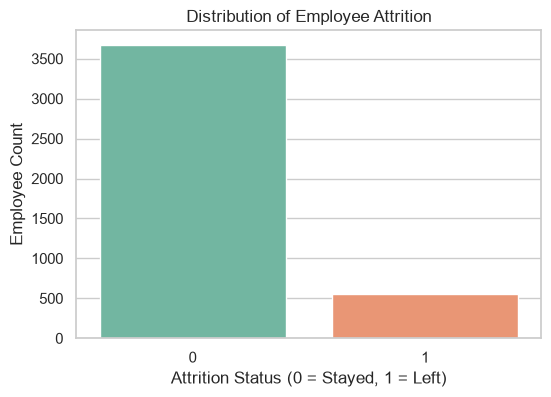

Stayed (0): 86.85%
Left (1): 13.15%


In [7]:
# Visualize the target variable balance (is_attrition)
plt.figure(figsize=(6, 4))
sns.countplot(x='is_attrition', data=df_ee, palette='Set2', hue='is_attrition', legend=False)
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition Status (0 = Stayed, 1 = Left)')
plt.ylabel('Employee Count')
plt.show()

# Print exact percentages
attrition_counts = df_ee['is_attrition'].value_counts(normalize=True) * 100
print(f"Stayed (0): {attrition_counts.get(0, 0):.2f}%")
print(f"Left (1): {attrition_counts.get(1, 0):.2f}%")

### 3. Data Preparation & Stratified Split
We define our feature matrix (`X`) and target vector (`y`). We use a stratified split to ensure our training and test sets maintain the same proportion of leavers as the overall dataset.

In [8]:
# Define features and target variable
X = df_ee[[
    'base_salary', 'performance_rating', 'tenure_years', 
    'age', 'engagement_score', 'manager_satisfaction', 
    'work_life_balance_score'
]]
y = df_ee['is_attrition']

# Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (3382, 7)
Test set shape: (846, 7)


### 4. Model 1: Logistic Regression (Linear Baseline)
To establish a baseline, we train a Logistic Regression model. Because our features span very different numerical scales, we use a scikit-learn pipeline to automatically impute missing values and scale features. 

We also apply `class_weight='balanced'` to prevent the model from ignoring the minority class (leavers).

In [9]:
# Pipeline: Impute missing values -> Scale data -> Logistic Regression
lr_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=7, class_weight='balanced')
)

# Fit the model
lr_model.fit(X_train, y_train)

# Extract and display coefficients for interpretability
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.named_steps['logisticregression'].coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("--- Logistic Regression Coefficients ---")
display(coefficients)

# Evaluate predictions on the test set
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print(f"\nLogistic Regression ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_preds))

--- Logistic Regression Coefficients ---


,Feature,Coefficient
2,tenure_years,-0.749192
5,manager_satisfaction,-0.120401
1,performance_rating,-0.100552
4,engagement_score,0.098385
6,work_life_balance_score,-0.048745
0,base_salary,-0.042632
3,age,-0.005075



Logistic Regression ROC-AUC Score: 0.7195

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74       735
           1       0.22      0.71      0.33       111

    accuracy                           0.63       846
   macro avg       0.58      0.66      0.54       846
weighted avg       0.84      0.63      0.69       846



### 5. Model 2: Random Forest Classifier
Next, we train a Random Forest model to capture complex, non-linear interactions and threshold rules between employee satisfaction metrics and turnover risk.

In [10]:
# Initialize and train Random Forest Classifier
# Pipeline: Impute missing values -> Random Forest
rf_model = make_pipeline(
    SimpleImputer(strategy='median'),
    RandomForestClassifier(random_state=7, class_weight='balanced')
)

rf_model.fit(X_train, y_train)

# Review feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.named_steps['randomforestclassifier'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Random Forest Feature Importances ---")
display(importances)

# Evaluate predictions on the test set
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print(f"\nRandom Forest ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))

--- Random Forest Feature Importances ---


,Feature,Importance
2,tenure_years,0.294667
0,base_salary,0.182298
3,age,0.150722
5,manager_satisfaction,0.104960
6,work_life_balance_score,0.103270
4,engagement_score,0.103247
1,performance_rating,0.060835



Random Forest ROC-AUC Score: 0.7336

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       735
           1       0.53      0.33      0.41       111

    accuracy                           0.87       846
   macro avg       0.72      0.64      0.67       846
weighted avg       0.86      0.87      0.86       846



### 6. Model Comparison & Visualization
To conclude our technical evaluation, we plot the **ROC curves** for both models on the same axes to visualize their true predictive discrimination performance side-by-side.

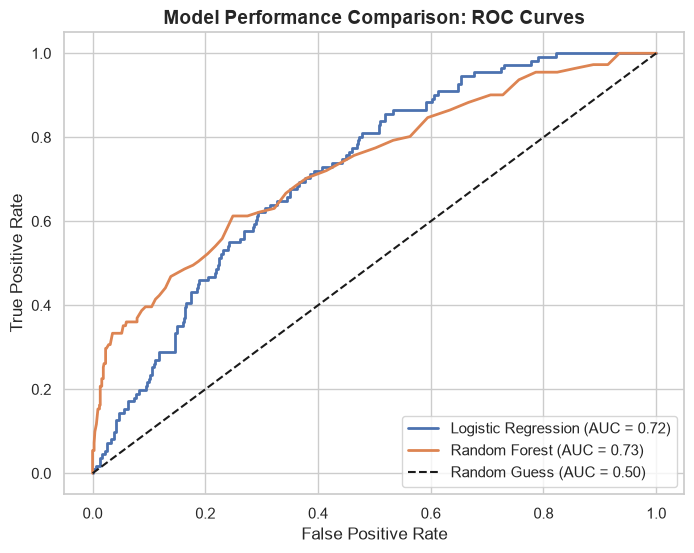

In [11]:
# Calculate ROC curve metrics
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Plot comparative ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model Performance Comparison: ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.show()

### 7. Executive Summary & Strategic Takeaways
#### Executive Summary

The latest predictive modeling on the updated employee dataset ($N = 846$) successfully identifies key behavioral, tenure-related, and demographic drivers of attrition. 

* **Model Performance:** The Random Forest Classifier outperforms the linear baseline, delivering a superior ROC-AUC of 0.7336 and a high overall accuracy of 87%. Crucially, it achieves a much healthier precision (53%) for predicting actual departures compared to the Logistic Regression model, making it a more reliable operational tool for HR intervention.
* **Primary Attrition Driver:** Tenure is unequivocally the single most powerful predictor of retention. Both models rank `tenure_years` as the dominant factor, indicating a critical vulnerability window (likely early tenure) where employees are most at risk of leaving.
* **Secondary Drivers:** Compensation (`base_salary`) and employee maturity (`age`) play massive non-linear roles in the Random Forest model, while cultural elements like `manager_satisfaction` and work-life balance consistently anchor employee retention across both algorithmic frameworks.


---

#### Strategic Takeaways & Actionable Recommendations

**1. Target Onboarding and Early-Tenure Retention Programs**
  * **The Insight:** Tenure commands nearly 30% of the Random Forest's feature importance and heavily reduces attrition log-odds in linear modeling. 
  * **Actionable Step:** Design specialized engagement checkpoints at critical tenure milestones (e.g., the 90-day mark, 6-month mark, and 1-year anniversary). Transition general retention efforts into targeted "early-career tenure defense" initiatives.

**2. Re-Evaluate Compensation Competitiveness for Mid-to-Senior Bands**
  * **The Insight:** `base_salary` ranks as the second most important feature (18.2%) in the Random Forest model, proving that non-linear salary thresholds heavily dictate whether employees stay or seek external markets.
  * **Actionable Step:** Conduct a localized market compensation review, specifically targeting roles and bands that show high attrition susceptibility to ensure pay equity and market alignment.

**3. Operationalize Manager Effectiveness Training**
  * **The Insight:** `manager_satisfaction` consistently reduces attrition risk across models and commands over 10% predictive weight. Poor leadership alignment is an active catalyst for turnover.
  * **Actionable Step:** Implement mandatory leadership coaching for supervisors and leads, focusing on management styles, regular feedback loops, and psychological safety.

**4. Deploy the Random Forest Model as an Early-Warning HR Dashboard**
  * **The Insight:** The Random Forest's 53% precision and 87% accuracy provide a balanced sweet spot to flag flight risks without overwhelming HR teams with false positives.
  * **Actionable Step:** Integrate this model into a monthly automated HR reporting pipeline to flag individual employees hitting high-risk thresholds, allowing People Operations to initiate proactive retention conversations.
